# Working with Text

## Basic steps
1. Use `select_font_face` to choose a font for the text
2. Use `select_font_size` to set the size (in pixels)
3. Set the color the usual way with `set_source_rgb`
4. Use `move_to` to set the text starting point (baseline for first character)
5. Use `show_text` to draw the characters.

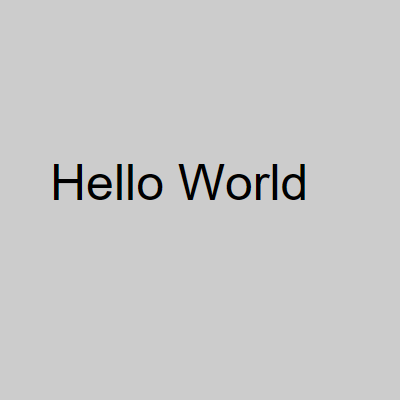

In [22]:
from IPython.core.display import Image
import cairo

OUTPUT_DIR = "output/"

surface = cairo.ImageSurface(cairo.FORMAT_RGB24, 400, 400)
ctx = cairo.Context(surface)
ctx.set_source_rgb(0.8, 0.8, 0.8)
ctx.paint()

# Select font
ctx.select_font_face("Montserrat")
ctx.set_font_size(50)

# Add text
ctx.set_source_rgb(0, 0, 0)
ctx.move_to(50, 200)
ctx.show_text("Hello World")

image_path = f"{OUTPUT_DIR}hello_world_text.png"
surface.write_to_png(image_path)
Image(image_path)

## Fonts and Font Families
### Font Families with Examples:
- Serif -> Use marks to decorate letters and shapes e.g.: Times
- Sans Serif -> "Without Decoration" e.g.: Arial
- Monospace -> All characters have the same width e.g.: Courier New
- Cursive -> Artistic, resembles handwriting e.g.: Freestyle Script
- Display -> Designed for signage (logos, signs), making characters legible and stand out e.g.: Dayton

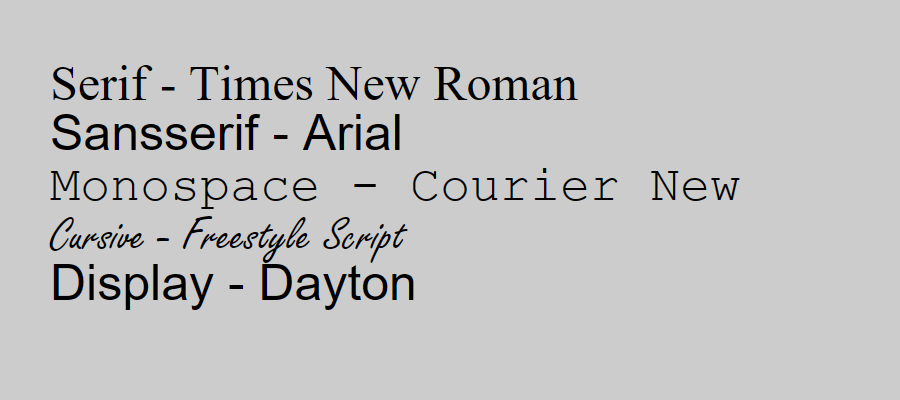

In [23]:
from IPython.core.display import Image
import cairo

surface = cairo.ImageSurface(cairo.FORMAT_RGB24, 900, 400)
ctx = cairo.Context(surface)
ctx.set_source_rgb(0.8, 0.8, 0.8)
ctx.paint()

# Font size and color
ctx.set_font_size(50)
ctx.set_source_rgb(0, 0, 0)

# Font type: Times
ctx.select_font_face("Times New Roman")
ctx.move_to(50, 100)
ctx.show_text("Serif - Times New Roman")

# Font type: Arial
ctx.select_font_face("Arial CE")
ctx.move_to(50, 150)
ctx.show_text("Sansserif - Arial")

# Font type: Courier New
ctx.select_font_face("Courier New")
ctx.move_to(50, 200)
ctx.show_text("Monospace - Courier New")

# Font type: Freestyle Script
ctx.select_font_face("Freestyle Script")
ctx.move_to(50, 250)
ctx.show_text("Cursive - Freestyle Script")

# Font type: Dayton
ctx.select_font_face("Dayton")
ctx.move_to(50, 300)
ctx.show_text("Display - Dayton")

image_path = f"{OUTPUT_DIR}font_types_text.png"
surface.write_to_png(image_path)
Image(image_path)

## Font Styles
- Italic: `cairo.FontSlant.ITALIC`, `cairo.FontSlant.OBLIQUE`
- Bold: `cairo.FontWeight.BOLD`

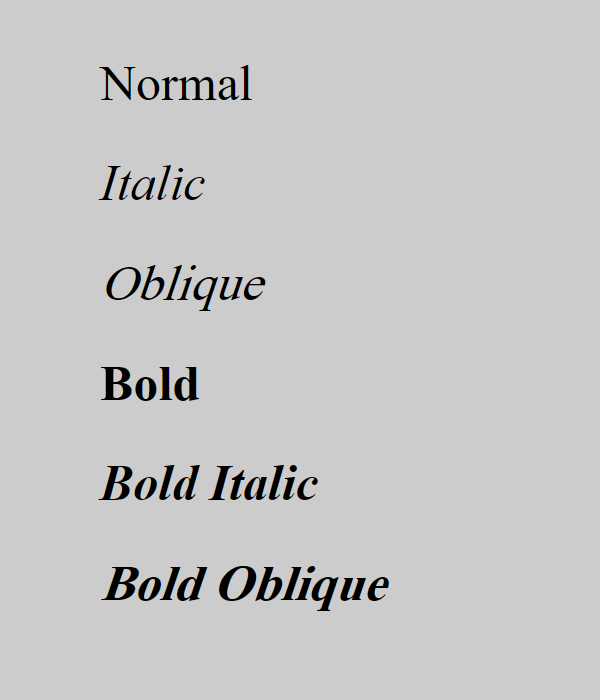

In [24]:
from IPython.core.display import Image
import cairo

surface = cairo.ImageSurface(cairo.FORMAT_RGB24, 600, 700)
ctx = cairo.Context(surface)
ctx.set_source_rgb(0.8, 0.8, 0.8)
ctx.paint()

ctx.set_font_size(50)
ctx.set_source_rgb(0, 0, 0)

# Normal
ctx.select_font_face("Times New Roman", cairo.FontSlant.NORMAL)
ctx.move_to(100, 100)
ctx.show_text("Normal")

# Italic
ctx.select_font_face("Times New Roman", cairo.FontSlant.ITALIC)
ctx.move_to(100, 200)
ctx.show_text("Italic")

# Oblique
ctx.select_font_face("Times New Roman", cairo.FontSlant.OBLIQUE)
ctx.move_to(100, 300)
ctx.show_text("Oblique")

# Bold text
ctx.select_font_face("Times New Roman", cairo.FontSlant.NORMAL, cairo.FontWeight.BOLD)
ctx.move_to(100, 400)
ctx.show_text("Bold")

ctx.select_font_face("Times New Roman", cairo.FontSlant.ITALIC, cairo.FontWeight.BOLD)
ctx.move_to(100, 500)
ctx.show_text("Bold Italic")

ctx.select_font_face("Times New Roman", cairo.FontSlant.OBLIQUE, cairo.FontWeight.BOLD)
ctx.move_to(100, 600)
ctx.show_text("Bold Oblique")

image_path = f"{OUTPUT_DIR}font_styles_text.png"
surface.write_to_png(image_path)
Image(image_path)

## Text Extents
- Text extents refer to the dimensions and positions of text strings when rendered with the current font.

![Xyz Text Extent](xyz_text_extent.png)


### Properties of a text extent
- `(x, y)`: The point where the text will be positioned corresponding to the current point when `show_text` function is called.
- `width` and `height`: Size of the rectangle that tightly encloses the marked area where the text is painted.
- `x_bearing`: Distance from `(x, y)` to the left-hand side of the text. The value is positive if the text rectangle starts to the left of `(x, y)`, and negative if the text rectangle starts to the right.
- `y_bearing`: Distance from `(x, y)` to the top of the text rectangle. Most Latin characters have negative values for `y_bearing` since the text extends **above** the baseline. (Note: going down is positive)
- `dx (x_advance)` and `dy (y_advance)`: Point at which the next text string will be placed, following along the present text string.

## Text Rectangle dimensions:
- Top left: `(x + x_bearing, y + y_bearing)`
- Size of rectangle: `width` by `height`

In [4]:
import cairo
import pandas as pd

surface = cairo.ImageSurface(cairo.FORMAT_RGB24, 400, 400)
ctx = cairo.Context(surface)
ctx.set_source_rgb(0.8, 0.8, 0.8)
ctx.paint()

# Text extent 
ctx.set_font_size(100)
# df = pd.DataFrame(ctx.text_extents("ABC"))
# df
ctx.text_extents("ABC")

cairo.TextExtents(x_bearing=-1.146484375, y_bearing=-73.802734375, width=203.806640625, height=76.0234375, x_advance=205.615234375, y_advance=0.0)

## Text Alignments
- Left align: The default alignment (for LTR characters)
- Right align: move to `x - width`
- Center align: move to `x - width/2`

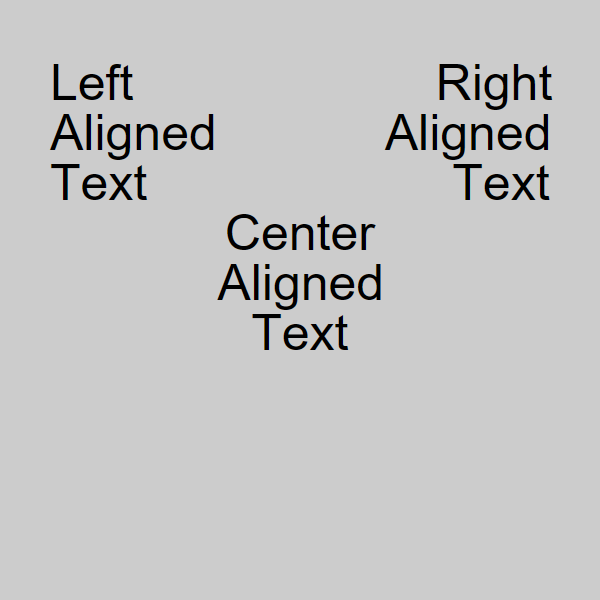

In [26]:
from IPython.core.display import Image
import cairo

OUTPUT_DIR = "output/"

def left_align(context, x, y, text):
    """ Aligns text to the left. """
    ctx.move_to(x, y)
    ctx.set_source_rgb(0, 0, 0)
    ctx.show_text(text)
    
def center_align(context, x, y, text):
    """ Aligns text to the center. """
    x_bearing, y_bearing, width, height, dx, dy = context.text_extents(text)
    context.move_to(x - width/2, y)
    context.set_source_rgb(0, 0, 0)
    ctx.show_text(text)
    
def right_align(context, x, y, text):
    """ Aligns text to the right. """
    x_bearing, y_bearing, width, height, dx, dy = context.text_extents(text)
    context.move_to(x - width, y)
    context.set_source_rgb(0, 0, 0)
    ctx.show_text(text)
    

# Set up the surface
surface = cairo.ImageSurface(cairo.FORMAT_RGB24, 600, 600)
ctx = cairo.Context(surface)
ctx.set_source_rgb(0.8, 0.8, 0.8)
ctx.paint()    
    
ctx.set_font_size(50)
ctx.select_font_face("Arial")

left_align(ctx, 50, 100, "Left")
left_align(ctx, 50, 150, "Aligned")
left_align(ctx, 50, 200, "Text")

center_align(ctx, 300, 250, "Center")
center_align(ctx, 300, 300, "Aligned")
center_align(ctx, 300, 350, "Text")

right_align(ctx, 550, 100, "Right")
right_align(ctx, 550, 150, "Aligned")
right_align(ctx, 550, 200, "Text")

image_path = f"{OUTPUT_DIR}text_alignment.png"
surface.write_to_png(image_path)
Image(image_path)

cairo.TextExtents(x_bearing=2.955078125, y_bearing=-36.791015625, width=28.708984375, height=37.791015625, x_advance=33.349609375, y_advance=0.0)


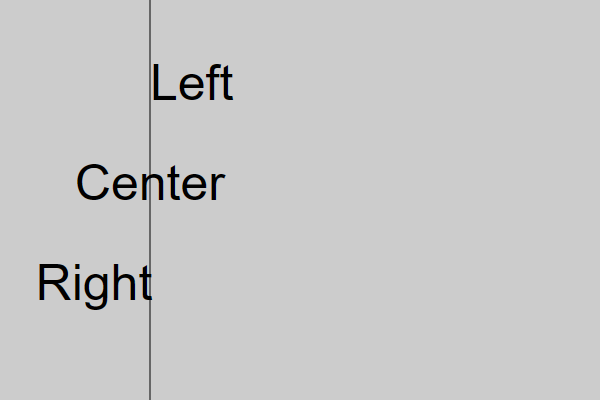

In [16]:
import cairo
from IPython.core.display import Image
import os

OUTPUT_DIR = "output/"
os.makedirs(OUTPUT_DIR, exist_ok=True)  # Ensure the output directory exists

def left_align(context, x, y, text):
    """ Aligns text to the left. """
    context.move_to(x, y)
    context.set_source_rgb(0, 0, 0)
    context.show_text(text)

def center_align(context, x, y, text):
    """ Aligns text to the center. """
    x_bearing, y_bearing, width, height, dx, dy = context.text_extents(text)
    context.move_to(x - width / 2, y)
    context.set_source_rgb(0, 0, 0)
    context.show_text(text)

def right_align(context, x, y, text):
    """ Aligns text to the right. """
    x_bearing, y_bearing, width, height, dx, dy = context.text_extents(text)
    context.move_to(x - width, y)
    context.set_source_rgb(0, 0, 0)
    context.show_text(text)

# Set up the surface
surface = cairo.ImageSurface(cairo.FORMAT_RGB24, 600, 400)
ctx = cairo.Context(surface)
ctx.set_source_rgb(0.8, 0.8, 0.8)  # Light gray background
ctx.paint()

# Set font
ctx.set_font_size(50)
ctx.select_font_face("Arial", cairo.FONT_SLANT_NORMAL, cairo.FONT_WEIGHT_NORMAL)

# Draw left-aligned text at y=100 (top)
left_align(ctx, 150, 100, "Left")

# Draw center-aligned text at y=200 (middle)
center_align(ctx, 150, 200, "Center")

# Draw right-aligned text at y=300 (bottom)
right_align(ctx, 150, 300, "Right")

ctx.move_to(150,0)
ctx.line_to(150,400)
ctx.set_line_width(1)
ctx.stroke()

print(ctx.text_extents("E"))

# Save and display the image
image_path = f"{OUTPUT_DIR}text_alignment_vertical.png"
surface.write_to_png(image_path)
Image(image_path)
